# 第一部分 载入库

In [1]:
import numpy as np
import pandas as pd

import cv2
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns

import PIL
from PIL import Image
from PIL import ImageStat

from tqdm.notebook import tqdm

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

import os

import collections

import shutil

from RandAugment import RandAugment

# 第二部分 数据检视&数据清洗

### [**数据检视**]

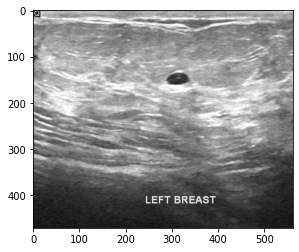

In [3]:
img = cv2.imread('..\\Data\\Dataset_BUSI_with_GT\\benign\\benign (1).png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [56]:
image_address = '..\\Data\\Dataset_BUSI_with_GT\\'

# 第二部分 数据集划分


### [**整理数据集**]

1. 从原数据中分理出用于测试集、验证集

1.1 划分测试集

In [5]:
import random
import math
import tqdm

先对各类文件夹中的数量进行汇总

In [11]:
benign_adr = '..\\Data\\Dataset_BUSI_with_GT\\benign\\'
malignant_adr = '..\\Data\\Dataset_BUSI_with_GT\\malignant\\'
normal_adr = '..\\Data\\Dataset_BUSI_with_GT\\normal\\'
benign_instance_count = 0 
malignant_instance_count = 0
benign_count = 0 
malignant_count = 0
normal_count = 0

In [12]:
for file in os.listdir(os.path.join(benign_adr)):
    if 'mask' in file:
        benign_instance_count = benign_instance_count+1
    if 'mask' not in file:
        benign_count = benign_count+1
print('benign instance:',benign_instance_count)
print('benign picture:',benign_count)

benign instance: 454
benign picture: 437


In [13]:
for file in os.listdir(os.path.join(malignant_adr)):
    if 'mask' in file:
        malignant_instance_count = malignant_instance_count+1
    if 'mask' not in file:
        malignant_count = malignant_count+1
print('malignant instance:',malignant_instance_count)
print('malignant picture:',malignant_count)

malignant instance: 211
malignant picture: 210


In [14]:
for file in os.listdir(os.path.join(normal_adr)):
    if 'mask' not in file:
        normal_count = normal_count+1
print('malignant picture:',normal_count)

malignant picture: 133


Duplicated instances appear in the same picture!

由于文件命名的关系，此处根据图片进行数据集分割。 7:3的划分比例。

In [49]:
benign_train = []
malignant_train = []
normal_train = []
benign_test = []
malignant_test = []
normal_test = []

In [50]:
index = 0
while index < benign_count*0.3:
    selected = random.randrange(1,benign_count+1)
    if selected not in benign_test:
        benign_test.append(selected)
        index = index+1
index = 0
while index < malignant_count*0.3:
    selected = random.randrange(1,malignant_count+1)
    if selected not in malignant_test:
        malignant_test.append(selected)
        index = index+1
index = 0
while index < normal_count*0.3:
    selected = random.randrange(1,normal_count+1)
    if selected not in normal_test:
        normal_test.append(selected)
        index = index+1

In [51]:
len(benign_test)

132

In [52]:
len(malignant_test)

63

In [53]:
len(normal_test)

40

In [89]:
benign_test

[102,
 301,
 251,
 190,
 320,
 379,
 232,
 227,
 31,
 72,
 161,
 86,
 283,
 378,
 98,
 256,
 53,
 127,
 88,
 265,
 160,
 93,
 51,
 266,
 272,
 273,
 162,
 358,
 62,
 130,
 334,
 314,
 257,
 146,
 407,
 47,
 295,
 303,
 329,
 416,
 125,
 183,
 372,
 321,
 268,
 34,
 165,
 223,
 317,
 5,
 247,
 277,
 148,
 66,
 294,
 310,
 67,
 116,
 316,
 296,
 335,
 370,
 290,
 134,
 188,
 388,
 149,
 112,
 132,
 40,
 99,
 91,
 215,
 220,
 122,
 185,
 108,
 354,
 3,
 121,
 97,
 138,
 349,
 248,
 61,
 199,
 297,
 252,
 367,
 115,
 306,
 377,
 81,
 282,
 376,
 197,
 187,
 364,
 287,
 427,
 119,
 347,
 262,
 274,
 216,
 43,
 356,
 172,
 111,
 305,
 330,
 344,
 16,
 401,
 143,
 202,
 213,
 48,
 191,
 59,
 426,
 245,
 399,
 15,
 324,
 300,
 359,
 140,
 337,
 383,
 352,
 250]

In [65]:
#@save
def copyfile(filename, target_dir):
    """将文件复制到目标目录"""
    os.makedirs(target_dir, exist_ok=True)
    shutil.copy(filename, target_dir)

In [60]:
save_dir = '..\\Data\\BUSI\\'
data_dir = image_address
original_dir = [data_dir+'benign\\',data_dir+'malignant\\',data_dir+'normal\\']
test_set = [benign_test,malignant_test,normal_test]
label = ['benign','malignant','normal']

In [90]:
#@save
def reorg(data_dir, save_dir): 
    for i in range(0, 3):
        for file in os.listdir(os.path.join(original_dir[i])):
            indexleft = file.find('(')
            indexright = file.find(')')
            index = int(file[indexleft+1:indexright])
            if index in test_set[i]:
                if 'mask' in file:
                    copyfile(os.path.join(data_dir,label[i],file), os.path.join(save_dir,'test','mask',label[i]))
                else:
                    copyfile(os.path.join(data_dir,label[i],file), os.path.join(save_dir,'test','image',label[i]))
            else:
                if 'mask' in file:
                    copyfile(os.path.join(data_dir,label[i],file), os.path.join(save_dir,'train','mask',label[i]))
                else:
                    copyfile(os.path.join(data_dir,label[i],file), os.path.join(save_dir,'train','image',label[i]))
        print(label[i]+' finished')

In [91]:
reorg(data_dir, save_dir)

benign finished
malignant finished
normal finished
